# Task 3 - Fraud Detection

## Objective
Build a machine learning pipeline to detect fraudulent financial transactions from a highly imbalanced dataset.

## Dataset
Credit Card Fraud Detection Dataset containing transaction features, transaction amount, time, and fraud/non-fraud class labels.

## Tech Stack
Python, Pandas, NumPy, Scikit-learn, Imbalanced-learn (SMOTE), Matplotlib, Seaborn

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Initial Exploration

The dataset contains transaction-level information along with a binary target variable `Class`.

- `Class = 0` represents a non-fraudulent transaction.
- `Class = 1` represents a fraudulent transaction.
- `Time` represents the elapsed time from the first transaction.
- `Amount` represents the transaction amount.
- `V1` to `V28` are anonymized numerical features.

In [117]:
df = pd.read_csv("dataset/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [118]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sum())

Dataset Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
0


## 2. Duplicate Data Analysis

Duplicate records can affect the analysis and machine learning model by giving repeated observations more importance.

Therefore, duplicate rows are identified before building the models.

In [119]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [120]:
df[df.duplicated()].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


In [121]:
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [122]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


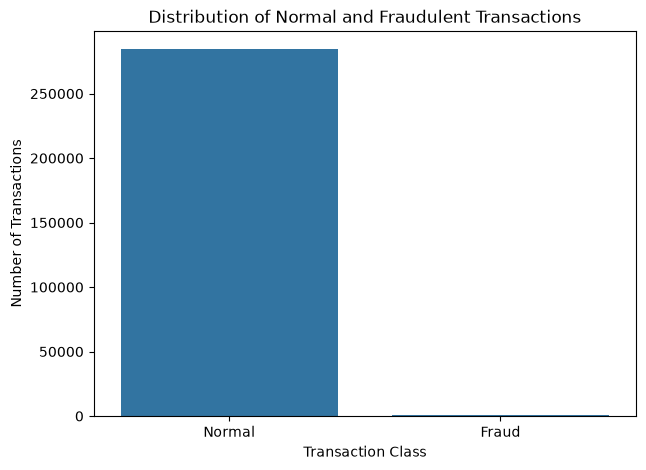

In [123]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Normal and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Normal", "Fraud"])

plt.show()

In [124]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


## 3. Class Imbalance Analysis

Fraud detection is a highly imbalanced classification problem because fraudulent transactions represent only a very small proportion of all transactions.

The class distribution is examined to understand the severity of the imbalance before model training.

In [125]:
class_counts = df["Class"].value_counts()
print(class_counts)

class_percentage = df["Class"].value_counts(normalize=True) * 100
print(class_percentage)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [126]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## 4. Exploratory Data Analysis

### 4.1 Transaction Amount Analysis

Transaction amounts are analysed separately for fraudulent and non-fraudulent transactions to understand whether transaction value shows different patterns between the two classes.

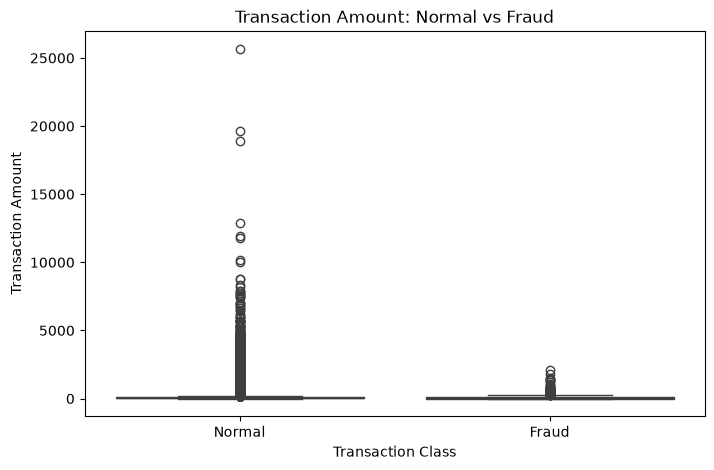

In [127]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount: Normal vs Fraud")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Normal", "Fraud"])

plt.show()

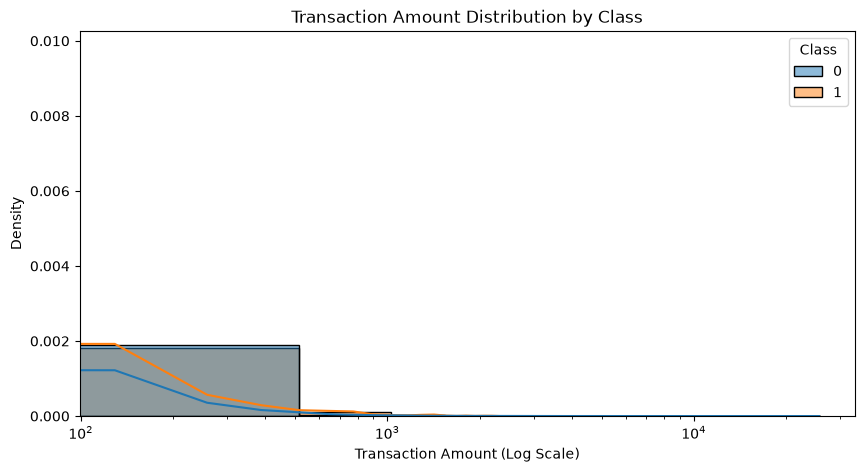

In [128]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.xscale("log")
plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount (Log Scale)")
plt.ylabel("Density")

plt.show()

## 4.2 Time-of-Day Analysis

The transaction Time variable is converted into an Hour feature to analyse the distribution of transactions and fraudulent transactions across different hours of the day.

Fraud counts and fraud rates are calculated for each hour to identify potential time-based patterns in fraudulent activity.

In [129]:
df["Hour"] = (df["Time"] / 3600) % 24

df["Hour"] = df["Hour"].astype(int)

df[["Time", "Hour", "Class"]].head()

,Time,Hour,Class
0,0.0,0,0
1,0.0,0,0
2,1.0,0,0
3,1.0,0,0
4,2.0,0,0


In [130]:
fraud_by_hour = df[df["Class"] == 1].groupby("Hour").size()

print(fraud_by_hour)

Hour
0      6
1     10
2     57
3     17
4     23
5     11
6      9
7     23
8      9
9     16
10     8
11    53
12    17
13    17
14    23
15    26
16    22
17    29
18    33
19    19
20    18
21    16
22     9
23    21
dtype: int64


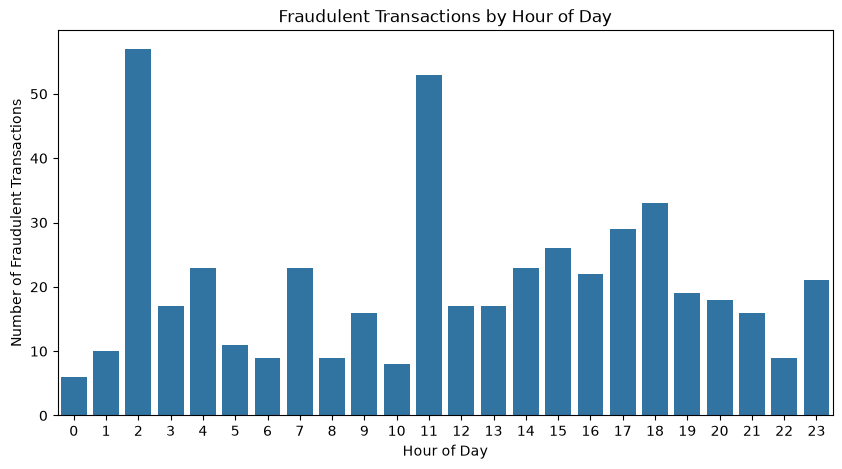

In [131]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df[df["Class"] == 1],
    x="Hour"
)

plt.title("Fraudulent Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

### Observation

The fraud rate varies across different hours of the day. Some hours show a noticeably higher fraud rate than others.

For example, the highest observed fraud rate occurs around hour 2, with a fraud rate of approximately 1.45%.

However, fraud rate should be interpreted together with the number of transactions at each hour rather than using fraud count alone.

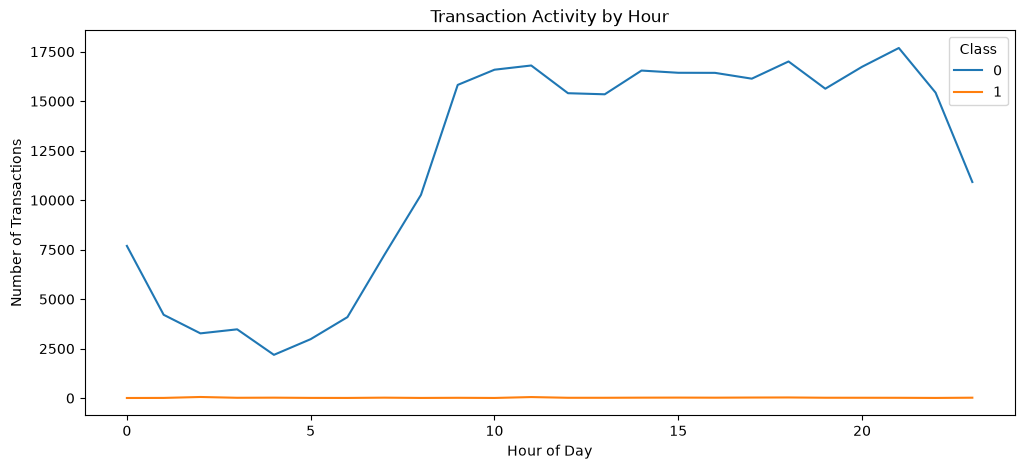

In [132]:
hour_class = df.groupby(["Hour", "Class"]).size().reset_index(name="Count")

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hour_class,
    x="Hour",
    y="Count",
    hue="Class"
)

plt.title("Transaction Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

In [133]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 5. Why Accuracy Alone Is Misleading

Accuracy is not sufficient for evaluating this fraud detection problem because the dataset is highly imbalanced.

Since the vast majority of transactions are non-fraudulent, a model could achieve very high accuracy by predicting most transactions as non-fraudulent while still failing to detect fraudulent transactions.

Therefore, Precision, Recall, F1-Score and ROC-AUC are used to evaluate the models more meaningfully.

Recall is particularly important when the goal is to detect as many fraudulent transactions as possible, while Precision is important for controlling false fraud alerts.

In [134]:
df.groupby("Class")[["Amount", "Time"]].mean()

,Amount,Time
Class,,
0,88.291022,94838.202258
1,122.211321,80746.806911


In [135]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [136]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicate_rows))

print("\nClass distribution among duplicate rows:")
print(duplicate_rows["Class"].value_counts())

Total duplicate rows: 1854

Class distribution among duplicate rows:
Class
0    1822
1      32
Name: count, dtype: int64


In [137]:
duplicate_rows = df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
)

duplicate_rows.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0,0


In [138]:
df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

print("\nClass distribution after removing duplicates:")
print(df_clean["Class"].value_counts())

Original rows: 284807
Rows after removing duplicates: 283726
Rows removed: 1081

Class distribution after removing duplicates:
Class
0    283253
1       473
Name: count, dtype: int64


In [139]:
class_percentage_clean = df_clean["Class"].value_counts(normalize=True) * 100

print(class_percentage_clean)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [140]:
hour_summary = df_clean.groupby("Hour").agg(
    total_transactions=("Class", "size"),
    fraud_transactions=("Class", "sum")
)

hour_summary["fraud_rate_percent"] = (
    hour_summary["fraud_transactions"] /
    hour_summary["total_transactions"] * 100
)

hour_summary

,total_transactions,fraud_transactions,fraud_rate_percent
Hour,,,
0,7647,6,0.078462
1,4208,10,0.237643
2,3308,48,1.451028
3,3487,17,0.487525
4,2204,23,1.043557
5,2988,11,0.368139
6,4082,9,0.220480
7,7233,23,0.317987
8,10232,9,0.087959


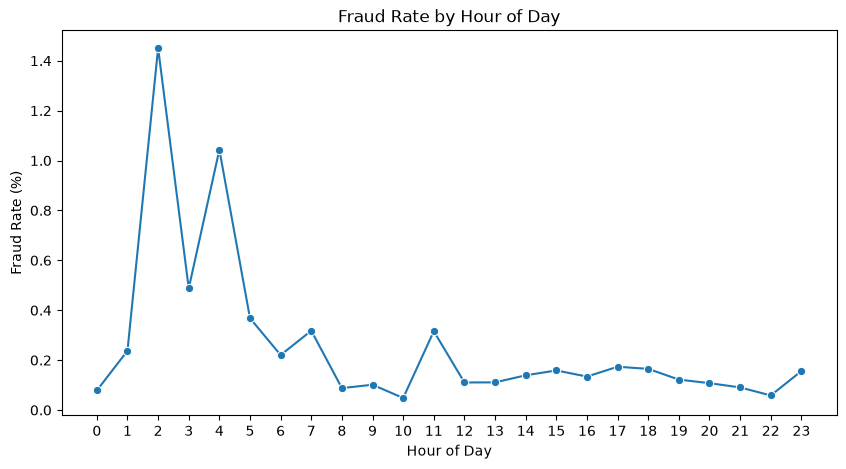

<Figure size 640x480 with 0 Axes>

In [141]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hour_summary.index,
    y=hour_summary["fraud_rate_percent"],
    marker="o"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

plt.savefig("outputs/fraud_rate_by_hour.png", dpi=300, bbox_inches="tight")
plt.show()

In [142]:
correlation = df_clean.corr(numeric_only=True)["Class"].sort_values(
    ascending=False
)

print(correlation)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
Hour     -0.016740
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


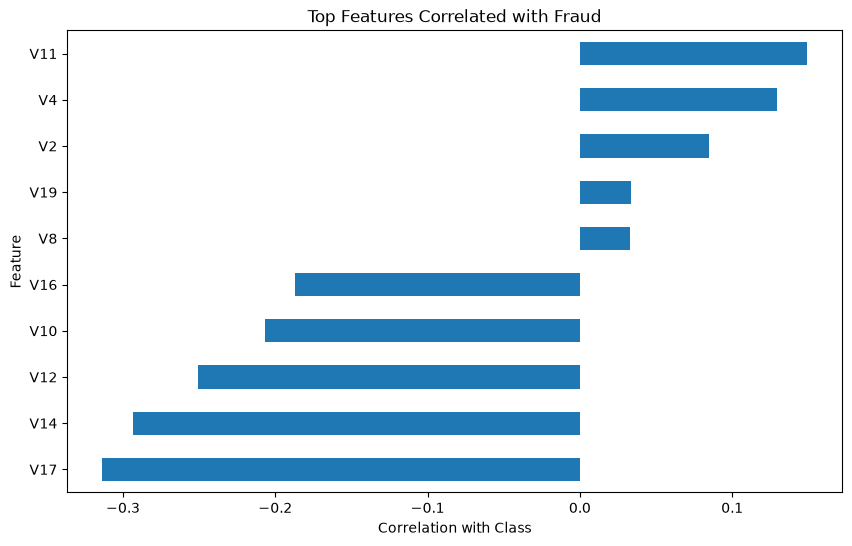

In [143]:
corr_features = correlation.drop("Class")

top_corr = pd.concat([
    corr_features.head(5),
    corr_features.tail(5)
])

plt.figure(figsize=(10, 6))

top_corr.sort_values().plot(kind="barh")

plt.title("Top Features Correlated with Fraud")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.savefig(
    "outputs/top_features_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [144]:
X = df_clean.drop("Class", axis=1)
y = df_clean["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 31)
Target shape: (283726,)


In [145]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set: (226980, 31)
Test set: (56746, 31)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [146]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nNew training shape:", X_train_smote.shape)

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64

New training shape: (453204, 31)


In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (453204, 31)
Scaled test shape: (56746, 31)


In [148]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train_smote)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [149]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression - Classification Report")
print(classification_report(y_test, y_pred_lr, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_lr), 4))

Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0     0.9998    0.9913    0.9955     56651
           1     0.1406    0.8526    0.2414        95

    accuracy                         0.9910     56746
   macro avg     0.5702    0.9219    0.6185     56746
weighted avg     0.9983    0.9910    0.9942     56746

Confusion Matrix:
[[56156   495]
 [   14    81]]
ROC-AUC Score: 0.9646


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest trained successfully.")

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest - Classification Report")
print(classification_report(y_test, y_pred_rf, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_rf), 4))

Random Forest - Classification Report
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     56651
           1     0.9012    0.7684    0.8295        95

    accuracy                         0.9995     56746
   macro avg     0.9504    0.8841    0.9146     56746
weighted avg     0.9994    0.9995    0.9995     56746

Confusion Matrix:
[[56643     8]
 [   22    73]]
ROC-AUC Score: 0.9507


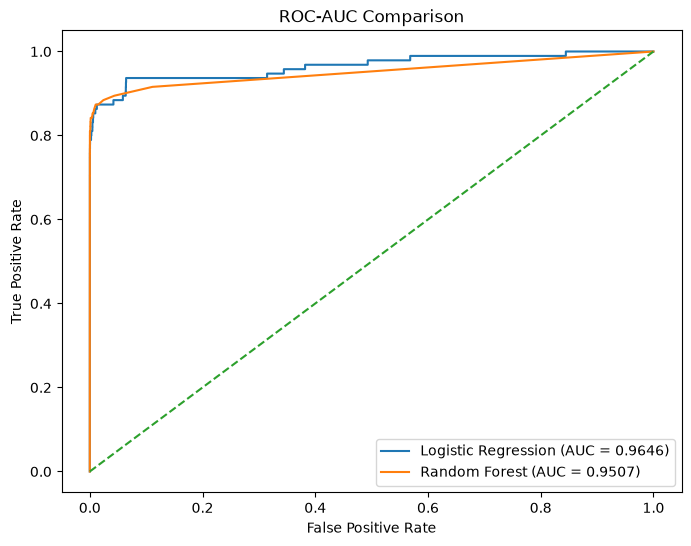

In [ ]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC-AUC Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig(
    "outputs/roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [0.1406, 0.9012],
    'Recall': [0.8526, 0.7684],
    'F1-Score': [0.2414, 0.8295],
    'ROC-AUC': [0.9646, 0.9507]
})

model_comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.1406,0.8526,0.2414,0.9646
1,Random Forest,0.9012,0.7684,0.8295,0.9507


In [ ]:
# Random Forest Feature Importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Features by Random Forest Importance:")
print(feature_importance.head(15))

Top 15 Features by Random Forest Importance:
V14    0.229394
V10    0.164196
V12    0.108078
V4     0.088294
V11    0.071929
V17    0.071911
V3     0.060649
V16    0.028076
V7     0.027145
V2     0.023990
V9     0.023407
V21    0.013735
V18    0.012696
V1     0.007527
V6     0.007073
dtype: float64


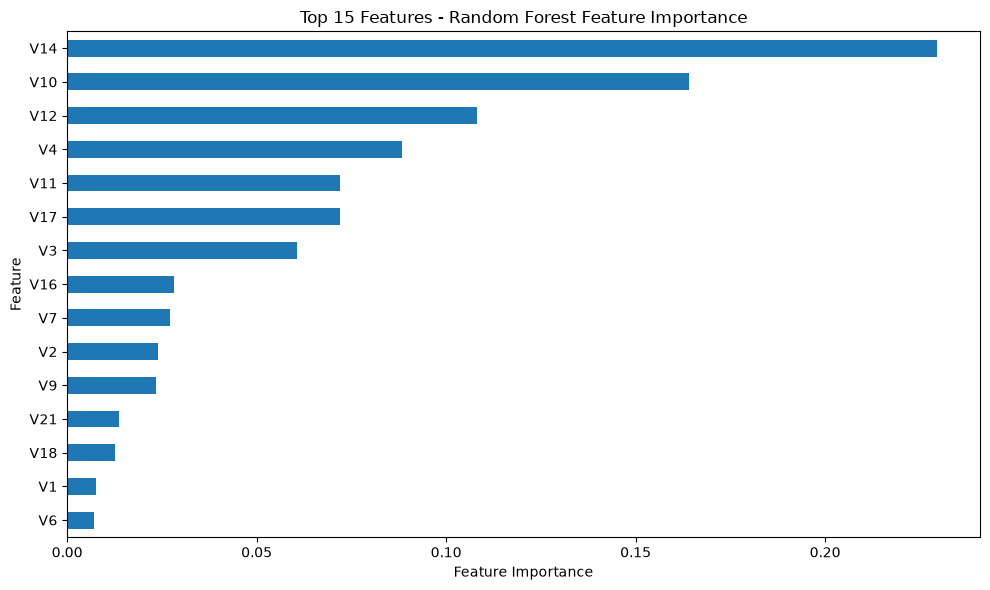

In [ ]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 Features - Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("outputs/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Logistic Regression Coefficient Analysis

coefficients = pd.Series(
    logistic_model.coef_[0],
    index=X.columns
).sort_values()

print("Top features with negative coefficients:")
print(coefficients.head(10))

print("\nTop features with positive coefficients:")
print(coefficients.tail(10))

Top features with negative coefficients:
V17    -9.677486
V14    -9.075647
V12    -8.615881
V10    -6.360483
V8     -3.452051
V16    -2.784790
V9     -1.474531
V18    -1.260057
Time   -0.947780
V2     -0.745888
dtype: float64

Top features with positive coefficients:
V28       0.278350
Amount    0.532820
V19       0.718034
V21       0.759543
V22       0.831479
Hour      0.868466
V5        2.062128
V11       2.190018
V4        3.443007
V1        4.487766
dtype: float64


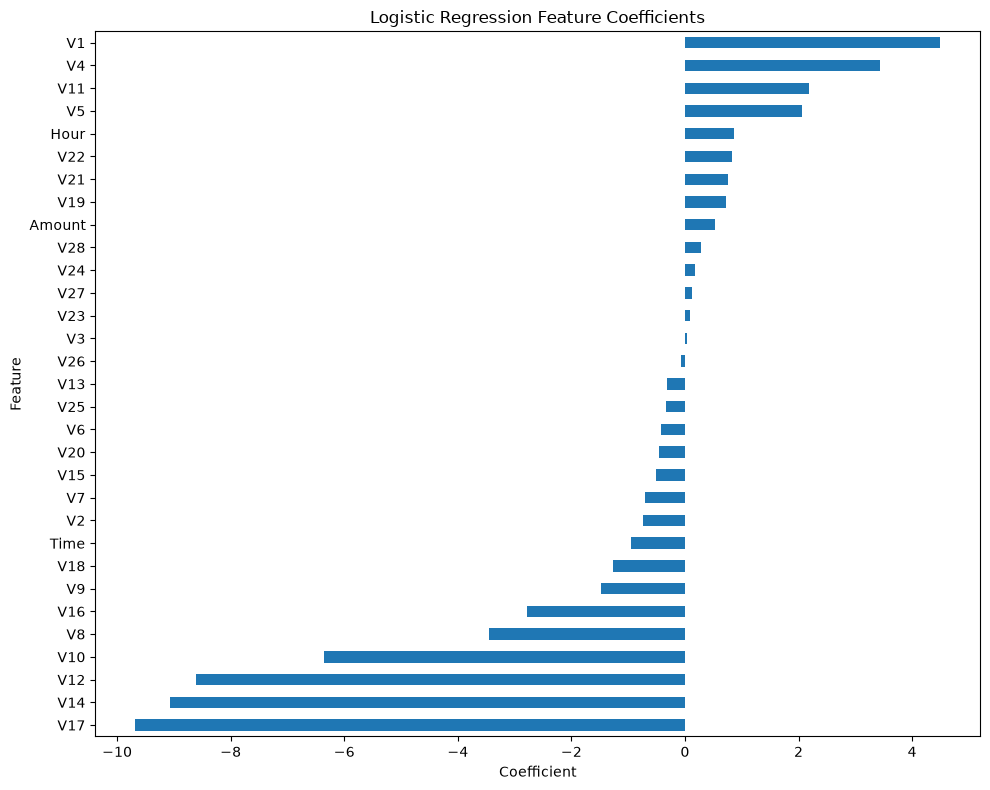

In [ ]:
plt.figure(figsize=(10, 8))

coefficients.plot(kind='barh')

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "outputs/logistic_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

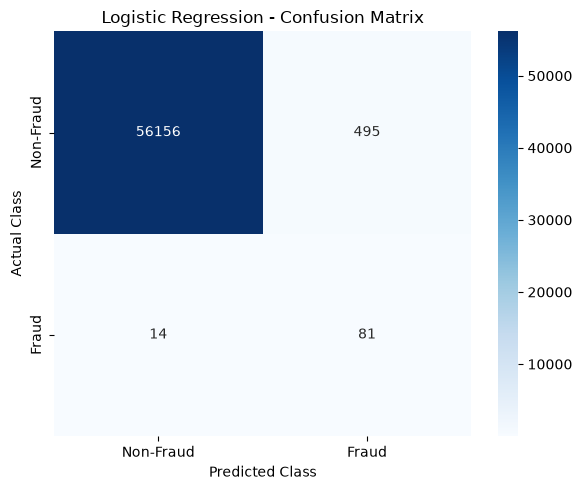

In [ ]:
# Confusion Matrix - Logistic Regression

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

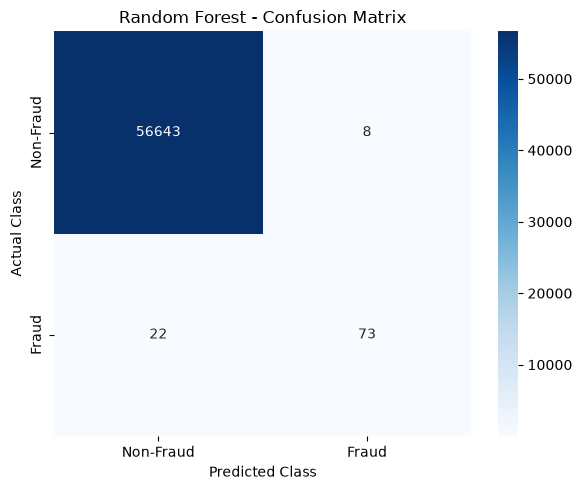

In [ ]:
# Confusion Matrix - Random Forest

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

In [ ]:
# Model Performance Comparison

model_comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.1406,0.8526,0.2414,0.9646
1,Random Forest,0.9012,0.7684,0.8295,0.9507


## Evaluation Metrics for Fraud Detection

Accuracy is not a reliable metric for this dataset because the data is highly imbalanced. Only about 0.17% of the transactions are fraudulent, so a model could achieve very high accuracy while still missing many fraudulent transactions.

### Precision

Precision measures how many transactions predicted as fraud are actually fraudulent.

A higher precision means fewer false fraud alerts.

### Recall

Recall measures how many of the actual fraudulent transactions are correctly detected.

For fraud detection, recall is particularly important because missing a fraudulent transaction can be costly.

### F1-Score

F1-score combines precision and recall into a single metric. It is useful when we need a balance between detecting fraud and reducing false alarms.

### ROC-AUC

ROC-AUC measures the model's ability to distinguish between fraudulent and non-fraudulent transactions across different classification thresholds.

### Model Comparison

Logistic Regression achieved a precision of 0.1406, recall of 0.8526, F1-score of 0.2414, and ROC-AUC of 0.9646.

Random Forest achieved a precision of 0.9012, recall of 0.7684, F1-score of 0.8295, and ROC-AUC of 0.9507.

The results show a trade-off between precision and recall. Logistic Regression detects a larger proportion of fraudulent transactions, while Random Forest produces substantially fewer false positive fraud predictions.

Therefore, the appropriate metric depends on the operational cost of false negatives versus false positives. For fraud detection, recall is important when missing fraudulent transactions is the primary concern, while precision becomes important when reducing false fraud alerts is a priority.

## Scalability: Handling 1 Million Transactions per Hour

The trained fraud detection models can be scaled to handle a much larger transaction volume, but the prediction pipeline would need to be optimized for real-time processing.

For 1 million transactions per hour, the system would need to process approximately 278 transactions per second.

### Scalability Considerations

- Use batch or real-time prediction depending on the application requirements.
- Keep preprocessing steps such as feature scaling consistent with the training pipeline.
- Use the trained Random Forest or Logistic Regression model for fast prediction.
- Parallel processing can be used to distribute prediction workloads.
- A production system could use streaming technologies such as Kafka for continuous transaction processing.
- The model and preprocessing pipeline can be deployed as an API or microservice.
- Model monitoring would be required to detect changes in transaction patterns and fraud rates.
- Periodic retraining would help the model adapt to new fraud patterns.

### Conclusion

The current models demonstrate that machine learning can identify fraudulent transactions despite the severe class imbalance in the dataset. SMOTE was used on the training data to address class imbalance, while stratified splitting preserved the fraud ratio in the test set.

The two models showed different precision-recall trade-offs. Logistic Regression achieved higher recall, while Random Forest achieved much higher precision and F1-score.

For a real-world deployment, the choice of model and classification threshold should depend on the relative cost of missed fraud and false fraud alerts.

## Final Conclusion

This project developed a machine learning pipeline for detecting fraudulent credit card transactions from a highly imbalanced dataset.

The dataset initially contained 284,807 transactions. After removing duplicate rows, 283,726 transactions remained, including 473 fraudulent transactions. Fraud represented only 0.16671% of the cleaned dataset, demonstrating the severe class imbalance problem.

SMOTE was applied only to the training data, increasing the minority class from 378 to 226,602 transactions. The test set was kept unchanged and stratified to provide a realistic evaluation.

Two machine learning models were trained:

- Logistic Regression
- Random Forest

Logistic Regression achieved a precision of 0.1406, recall of 0.8526, F1-score of 0.2414, and ROC-AUC of 0.9646.

Random Forest achieved a precision of 0.9012, recall of 0.7684, F1-score of 0.8295, and ROC-AUC of 0.9507.

The results demonstrate that fraud detection involves an important precision-recall trade-off. Logistic Regression detected more fraudulent transactions, while Random Forest generated substantially fewer false positive fraud predictions.

Feature analysis showed that features such as V14, V10, V12, V4, V11, and V17 had strong influence on the models.

Overall, the project demonstrates the importance of class imbalance handling, stratified evaluation, appropriate performance metrics, and feature analysis when developing machine learning systems for fraud detection.